# Pedestrian Trajectory Analysis — Yaounde

Interactive exploration of the Yaounde tracking results and comparison with ETH/UCY benchmarks.

**Workflow:**
1. Load trajectory CSV
2. Inspect basic statistics
3. Visualise heatmap & trajectories
4. Load ETH/UCY data
5. Side-by-side comparison plots

In [6]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from extract_traj import compute_speeds
from visualize import plot_heatmap, plot_trajectories, plot_speed_distribution
from compare_eth_ucy import load_eth_ucy, per_pedestrian_stats, plot_comparison

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load Yaounde Trajectories

In [7]:
df = pd.read_csv('../data/trajectories_yaounde.csv')
print(f'Unique pedestrians : {df["id"].nunique()}')
print(f'Total records      : {len(df)}')
print(f'Frame range        : {df["frame"].min()} - {df["frame"].max()}')
df.head(10)

Unique pedestrians : 1182
Total records      : 50310
Frame range        : 0 - 18043


,id,frame,x,y,speed_mps
0,1,0,576.51,363.36,NaN
1,1,1,576.87,362.83,0.384422
2,1,2,577.74,363.36,0.611235
3,1,3,579.56,363.87,1.134063
4,1,4,580.25,363.54,0.458912
5,1,5,582.21,365.87,1.826850
6,1,6,583.81,365.59,0.974589
7,1,7,584.25,367.67,1.275617
8,1,8,584.33,368.39,0.434658
9,1,9,585.73,370.84,1.693074


## 2. Basic Statistics

In [8]:
if 'speed_mps' not in df.columns:
    df = compute_speeds(df, fps=30.0, px_per_m=50.0)

stats = df.groupby('id')['speed_mps'].agg(['mean','median','max']).reset_index()
stats.columns = ['id', 'mean_speed', 'median_speed', 'max_speed']
print('Speed summary (m/s):')
print(stats.describe().round(3))

Speed summary (m/s):
             id  mean_speed  median_speed  max_speed
count  1182.000    1020.000      1020.000   1020.000
mean   2818.404       5.029         4.703     11.008
std    1649.645       5.520         5.498     11.860
min       1.000       0.027         0.027      0.027
25%    1448.750       1.071         0.982      2.192
50%    2798.500       2.734         2.454      5.649
75%    4194.500       6.964         6.385     17.703
max    5710.000      31.356        31.773     92.297


## 3. Visualisations

[visualize] Heatmap saved to ../results/heatmap.png
[visualize] Trajectory plot saved to ../results/trajectories.png
[visualize] Speed distribution saved to ../results/speed_distribution.png


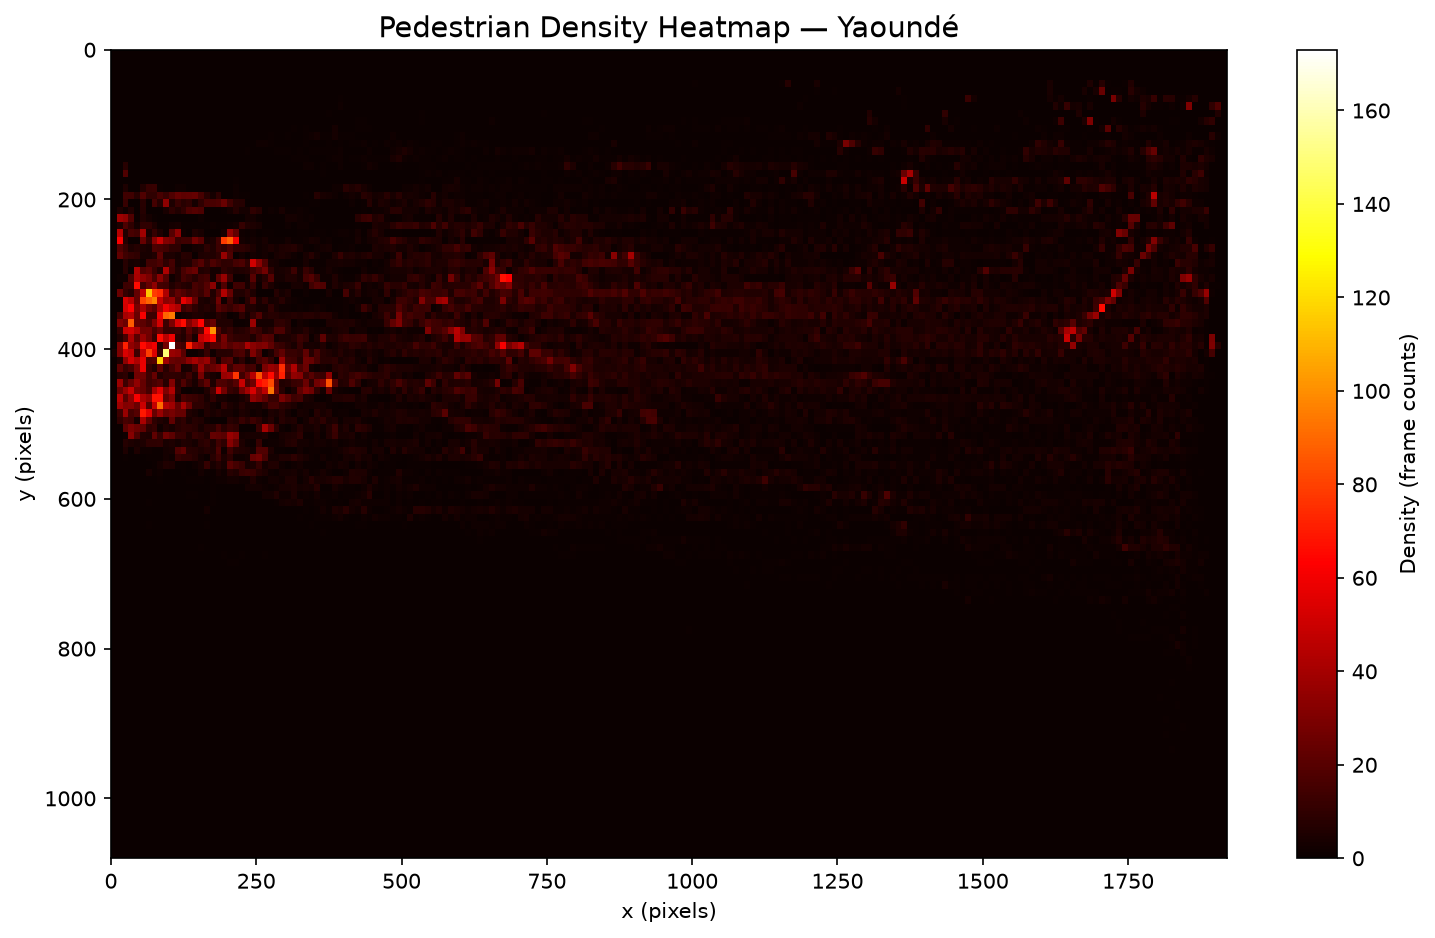

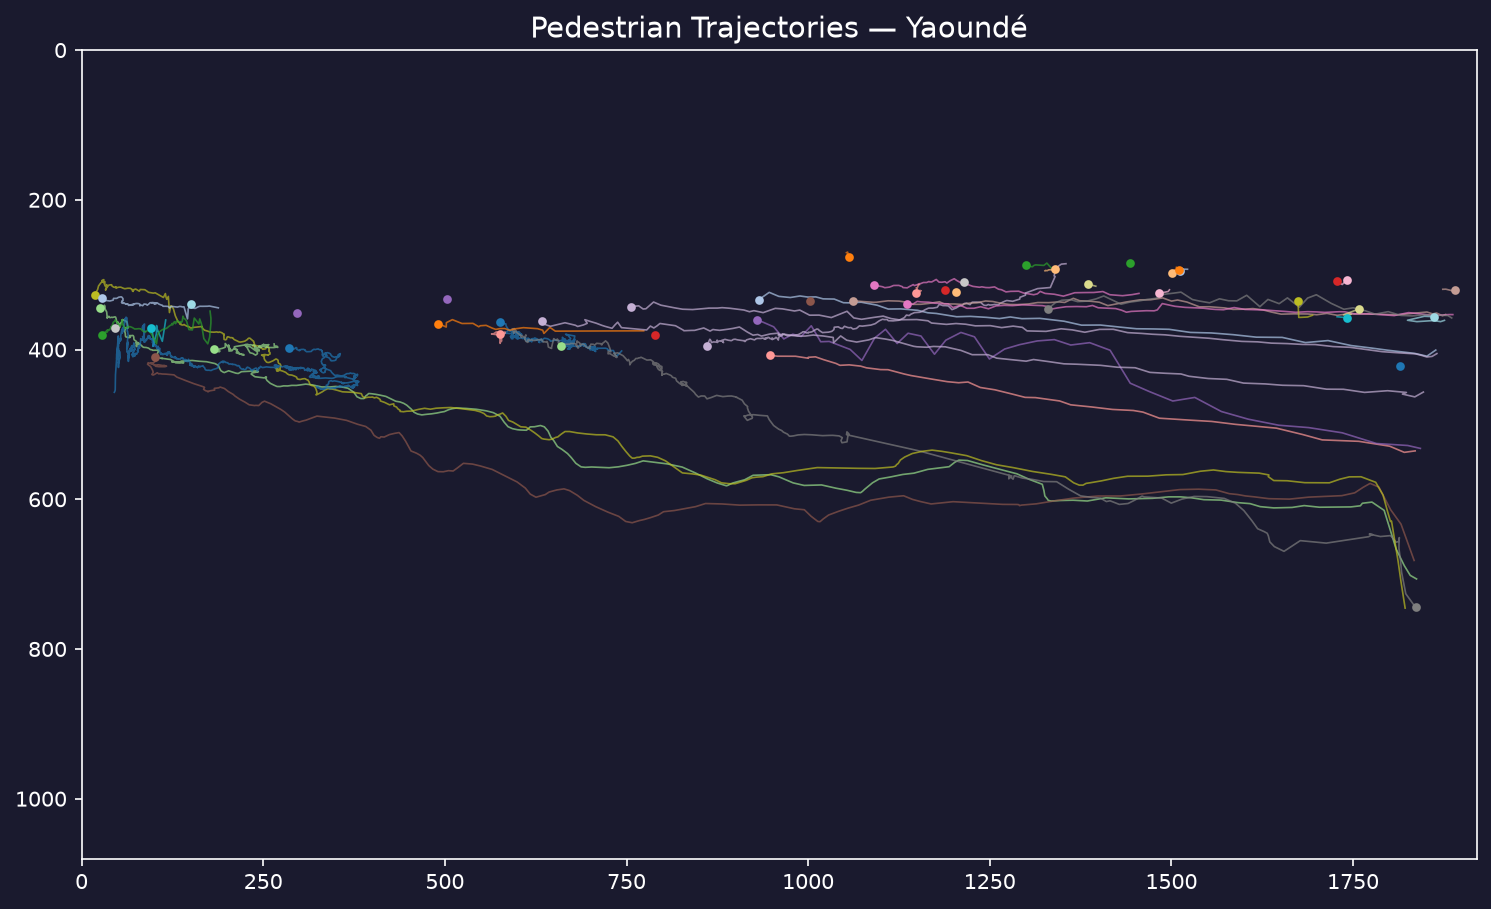

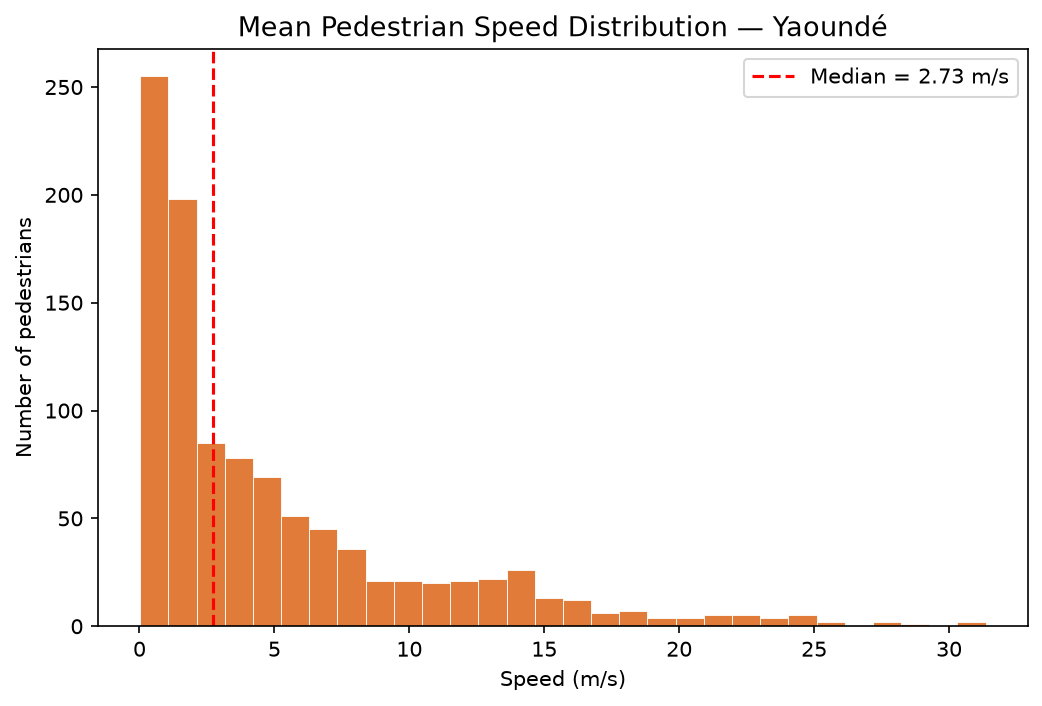

In [9]:
FRAME_W = 1920  # Samsung Galaxy A56, FHD
FRAME_H = 1080  # 1920x1080 @ 30 FPS -- Carrefour Melen, Yaounde

plot_heatmap(df, FRAME_W, FRAME_H, output='../results/heatmap.png')
plot_trajectories(df, FRAME_W, FRAME_H, output='../results/trajectories.png')
plot_speed_distribution(df, output='../results/speed_distribution.png')

# Display all three plots inline
from IPython.display import Image, display
display(Image('../results/heatmap.png'))
display(Image('../results/trajectories.png'))
display(Image('../results/speed_distribution.png'))


## 4. ETH/UCY Comparison

[compare] Comparison plot saved to ../results/speed_comparison.png
[compare] Summary table saved to ../results/comparison_summary.csv
            Metric Yaounde ETH/UCY
  Mean speed (m/s)   5.029   0.122
Median path length     1.1    13.5
  Median linearity   0.897   0.981


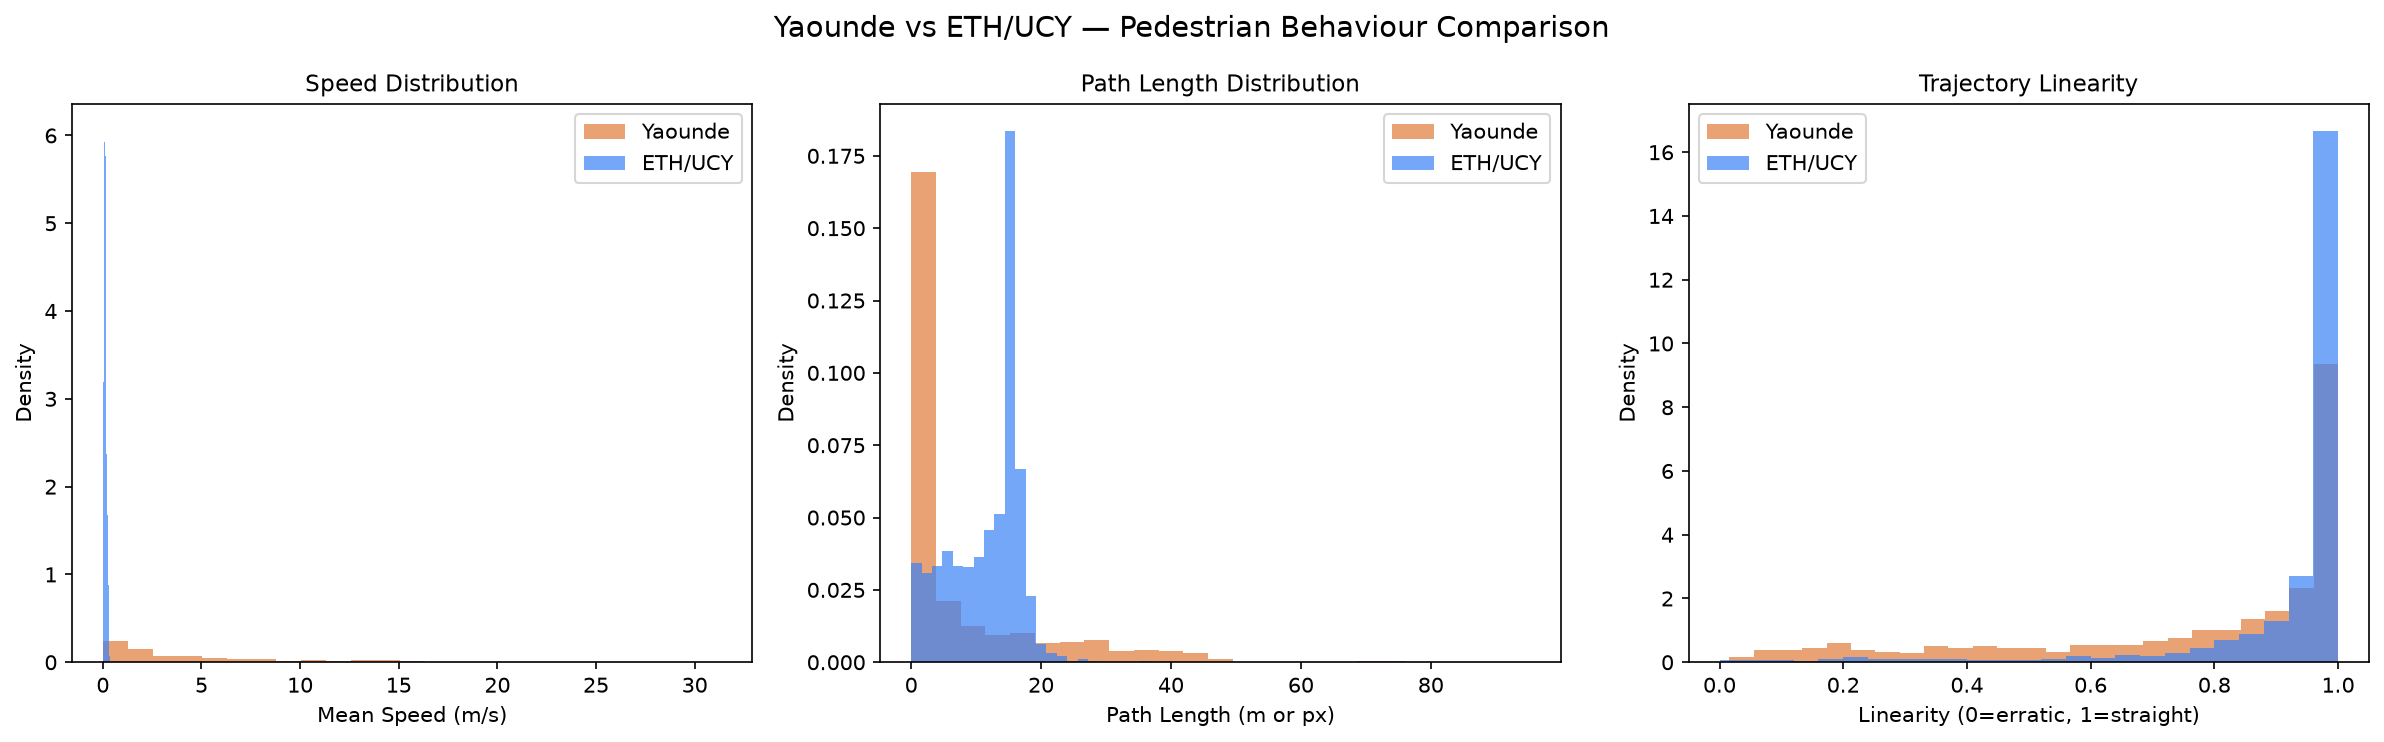

In [10]:
ETH_DIR = '../data/eth_ucy'  # place ETH/UCY .txt files here

try:
    eth_df = load_eth_ucy(ETH_DIR, fps=2.5)

    # Convert Yaounde pixels to metres for fair comparison
    PX_PER_M = 50.0
    yaounde_m = df.copy()
    yaounde_m['x'] = yaounde_m['x'] / PX_PER_M
    yaounde_m['y'] = yaounde_m['y'] / PX_PER_M

    yaounde_stats = per_pedestrian_stats(yaounde_m, label='Yaounde')
    eth_stats     = per_pedestrian_stats(eth_df,    label='ETH/UCY')

    plot_comparison(yaounde_stats, eth_stats, output_dir='../results')
    display(Image('../results/speed_comparison.png'))
except FileNotFoundError as e:
    print(f'ETH/UCY data not found: {e}')
    print('Download from: https://github.com/StanfordASL/Trajectron-plus-plus/tree/master/experiments/pedestrians/raw/raw/all_data')

## 5. Key Observations

> Fill in after running the analysis:

- **Speed**: Yaounde pedestrians move at X m/s vs Y m/s in ETH/UCY.
- **Linearity**: Yaounde trajectories are more erratic (lower linearity score).
- **Density**: Higher local density at intersections compared to ETH datasets.
- **Missing context**: ETH/UCY lacks moto-taxi interactions present in Yaounde.